In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

from metashapes.library import rectangle, ellipse, ngon, cross, ring, moon
from metashapes.canvas import Canvas
from metashapes.shape import Shape
from metashapes.utils.shp import to_wkt, scale, from_wkt
from metashapes.metasurface import Metasurface
from metashapes.fabtol import min_line_width_solid, min_spacing_gap

import shapely
import shapely.affinity as A

In [2]:
#Create canvas
Lx = 300
Ly = 300
H = 300
W = 300

canv = Canvas(-Lx/2, -Ly/2, Lx, Ly, H, W)

print(f'dx: {canv.dx}')
print(f'dy: {canv.dy}')
print(f'H: {canv.H}')
print(f'W: {canv.W}')

with canv.temporary_pixel_size(0.5):
    print(f'dx: {canv.dx}')
    print(f'dy: {canv.dy}')
    print(f'H: {canv.H}')
    print(f'W: {canv.W}')

print(f'dx: {canv.dx}')
print(f'dy: {canv.dy}')
print(f'H: {canv.H}')
print(f'W: {canv.W}')

dx: 1.0
dy: 1.0
H: 300
W: 300
dx: 0.5
dy: 0.5
H: 600
W: 600
dx: 1.0
dy: 1.0
H: 300
W: 300


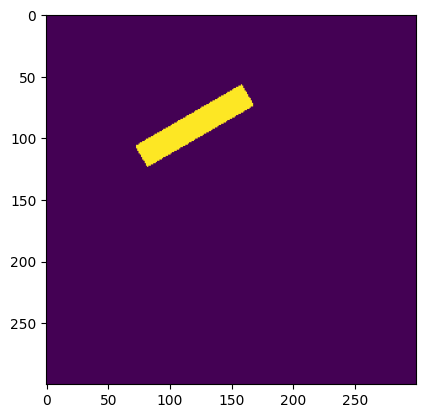

In [3]:
rect = rectangle((-30, 60), (100, 20), angle=30)
plt.imshow(rect.to_numpy(canv))

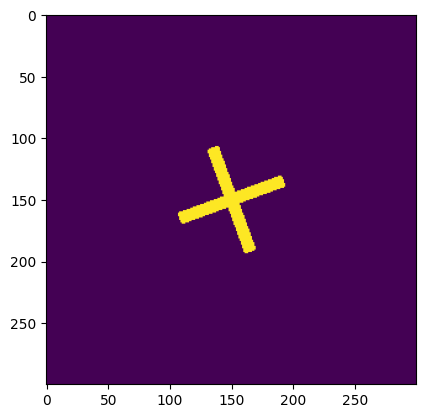

In [4]:
cross1 = cross((0, 0), 90, 10, angle = 20)
plt.imshow(cross1.to_numpy(canv))

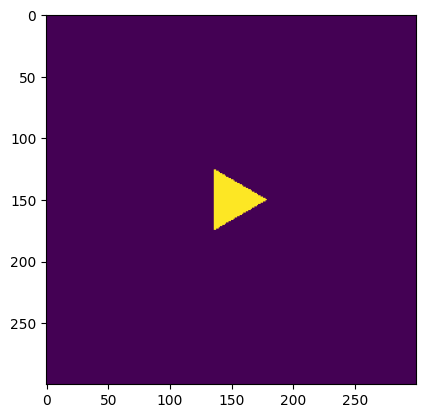

In [5]:
tri = ngon((0, 0), 50, 3, angle=30)
plt.imshow(tri.to_numpy(canv))

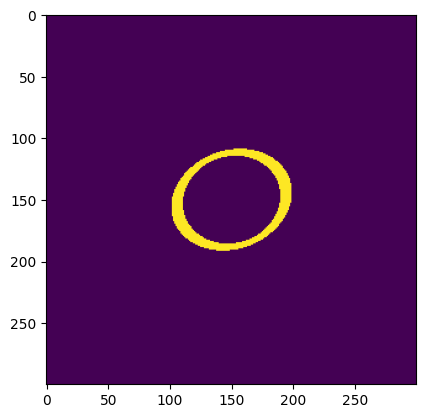

In [6]:
r = ring((0, 0), (50, 40), (40, 35), angle=10.0)
plt.imshow(r.to_numpy(canv))

Minimum line width in solid regions: 50.0 nm
Minimum spacing in gap regions: None nm


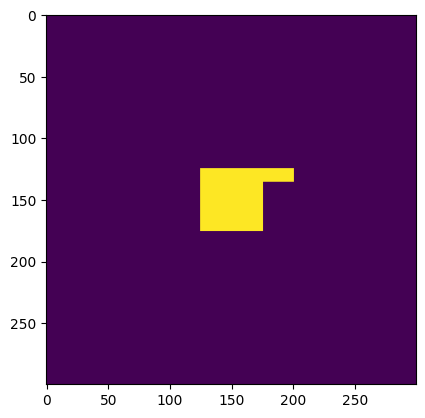

In [7]:
shape_c = rectangle((0, 0), (50, 50), angle=0).union(
    rectangle((20, 20), (60, 10), angle=0)
)

meta = Metasurface([shape_c], canv, thickness=200, inverted=False)
mfs_solid = min_line_width_solid(meta.unit_cell.geom)
print(f'Minimum line width in solid regions: {mfs_solid} nm')
mfs_gap = min_spacing_gap(meta.unit_cell.geom)
print(f'Minimum spacing in gap regions: {mfs_gap} nm')
plt.imshow(meta.to_numpy())

Image reconstruction error: 0.005216 (0 = perfect, 1 = total mismatch)


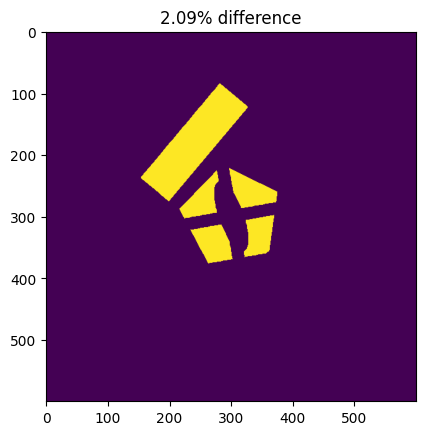

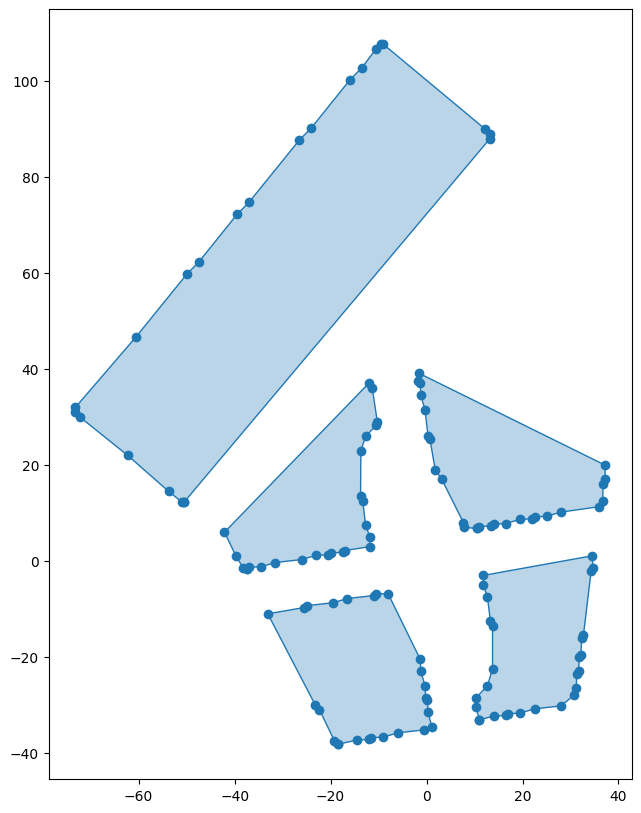

In [7]:
canv_new = canv
canv_new.set_grid(600, 600)
shape = ((r.difference(cross1)).intersection(tri)).union(rect)

shape2 = Shape.from_numpy(shape.to_numpy(canv), 
                          canv, 
                          simp_coeff=0.5,
                          sfd=False,
                          gaussian=True,
                          gauss_sigma=0.6,
                          verbose=True)


diff = (shape.to_numpy(canv).astype(float) - shape2.to_numpy(canv).astype(float))**2

plt.title(f'{diff.sum()/shape.area:.2%} difference')
plt.imshow(shape2.to_numpy(canv))
#plt.imshow(diff)
plt.show()

from shapely.plotting import plot_polygon # shapely>=2.0

fig, ax = plt.subplots(figsize=(10, 10))  # <- make bigger here
#plot_polygon(shape.geom.difference(shape2.geom), ax=ax)
plot_polygon(shape2.geom, ax=ax)
ax.set_aspect("equal")
plt.show()

Spacing: 0.0, Lx: 300, Ly: 300, dx: 1.0, dy: 1.0
Spacing: 25.0, Lx: 300, Ly: 300, dx: 1.0, dy: 1.0


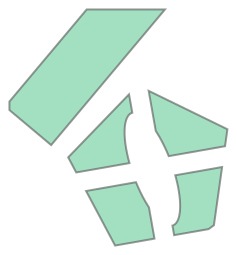

In [8]:
from metashapes.metasurface import Metasurface
canv_new = Canvas(-Lx/2, -Ly/2, Lx, Ly, 300, 300)
shape_new = scale(shape, 2)
meta = Metasurface([shape_new], canv_new, thickness=200, inverted=False)
print(f'Spacing: {meta.spacing}, Lx: {meta.L[0]}, Ly: {meta.L[1]}, dx: {meta.pixel_size[0]}, dy: {meta.pixel_size[1]}')
meta.spacing = 25
print(f'Spacing: {meta.spacing}, Lx: {meta.L[0]}, Ly: {meta.L[1]}, dx: {meta.pixel_size[0]}, dy: {meta.pixel_size[1]}')
meta.unit_cell

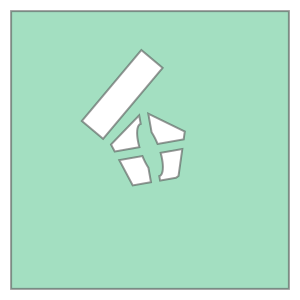

In [9]:
meta = Metasurface([shape], canv, thickness=200, inverted=True)
meta.unit_cell

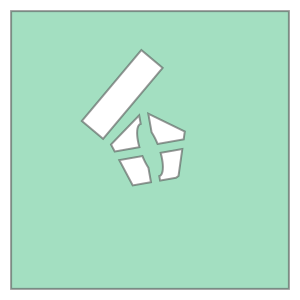

In [10]:
meta2 = Metasurface.from_parametric(meta.to_parametric())
meta2.unit_cell

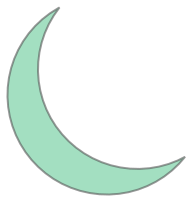

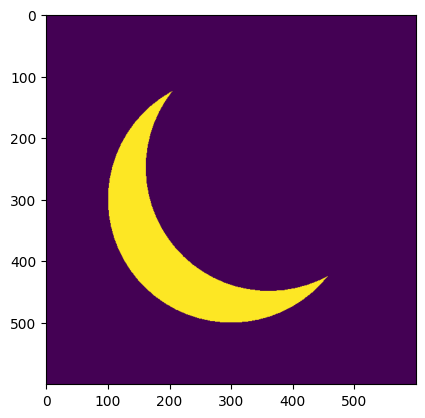

In [11]:
mn1 = moon((0,0), 100, 0.8, angle=40)
plt.imshow(mn1.to_numpy(canv))
mn1
